---
<!-- <img src="./plots/PAHdb_logo.png" alt="Alt Text"> -->
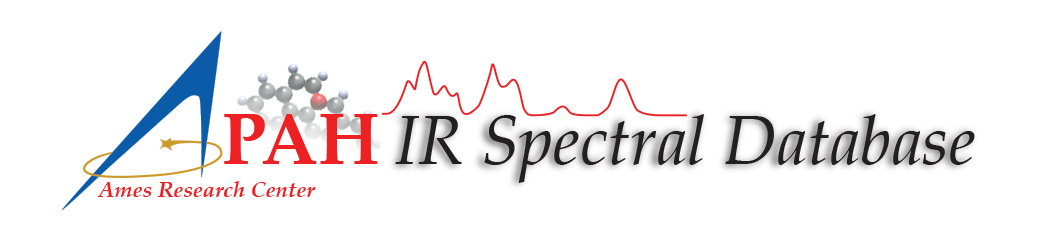 

[https://pahdb.github.io](https://pahdb.github.io)

<!-- <div style="text-align: center;"> -->
<!-- <img src="./plots/PAHdb_Documentation_Portal.png" alt="Alt Text" width="1000" height="900"> -->
<!-- </div> -->
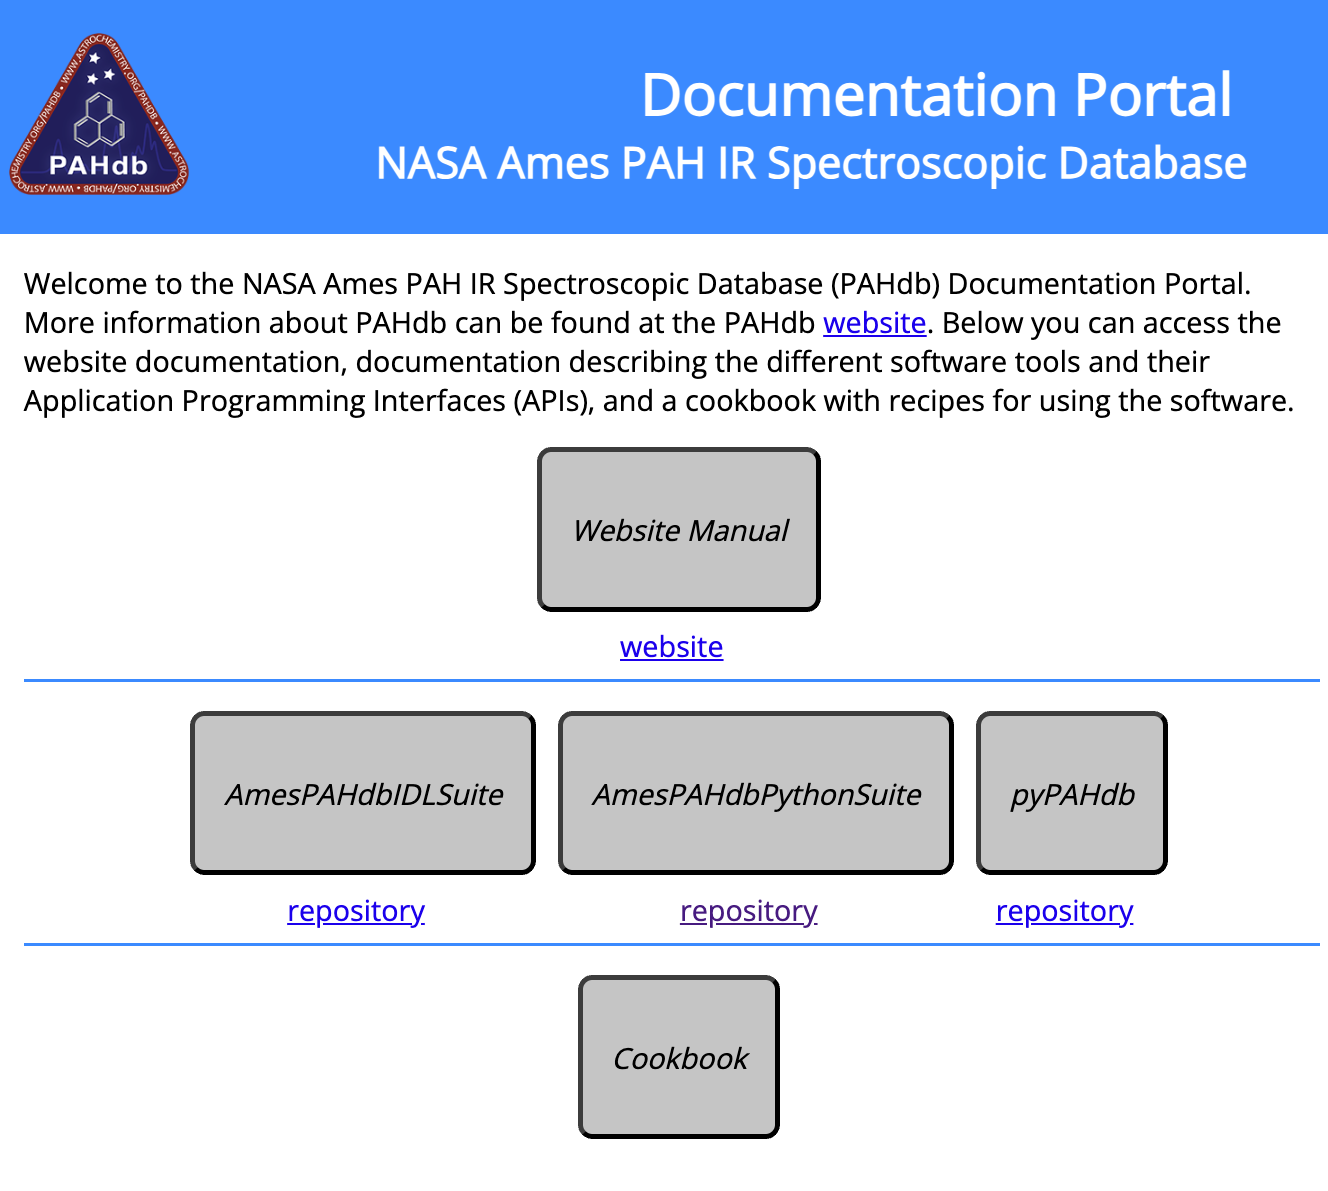 

---
<div style="text-align: center;">
    <h1>The AmesPAHdbPythonSuite</h1>
</div>

### Main Classes & Methods

1) ***AmesPAHdb***
    - Parse the database
    - Select PAHs

2) ***Transitions***
    - Get transitions
    - Apply emission model

3) ***Spectrum***
    - Fit the spectrum

4) ***Fitted***
    - Plotting
    - Obtaining parameters breakdown and statistics

### Secondary Classes & Methods

1) ***Species***
    - PAH details

2) ***Geometry***
    - Molecular geometric data
    - Plot PAHs

3) ***Coadded***
    - Coadd PAH spectra
---

---
## 1. Data preparation - Data Input Format

<!-- ### <ins>Data preparation</ins> -->
### Data preparation

- PAHdb will model the "pure" PAH spectrum, i.e., free of any continuum or emission lines components.
- There are several spectral decomposition codes or Python libraries and algorithms to fit lines, dust features, and continuum.


<!-- <img src="./plots/Decomposition_Methods_v02.001.png" alt="Alt Text" width="1200" height="700"> -->
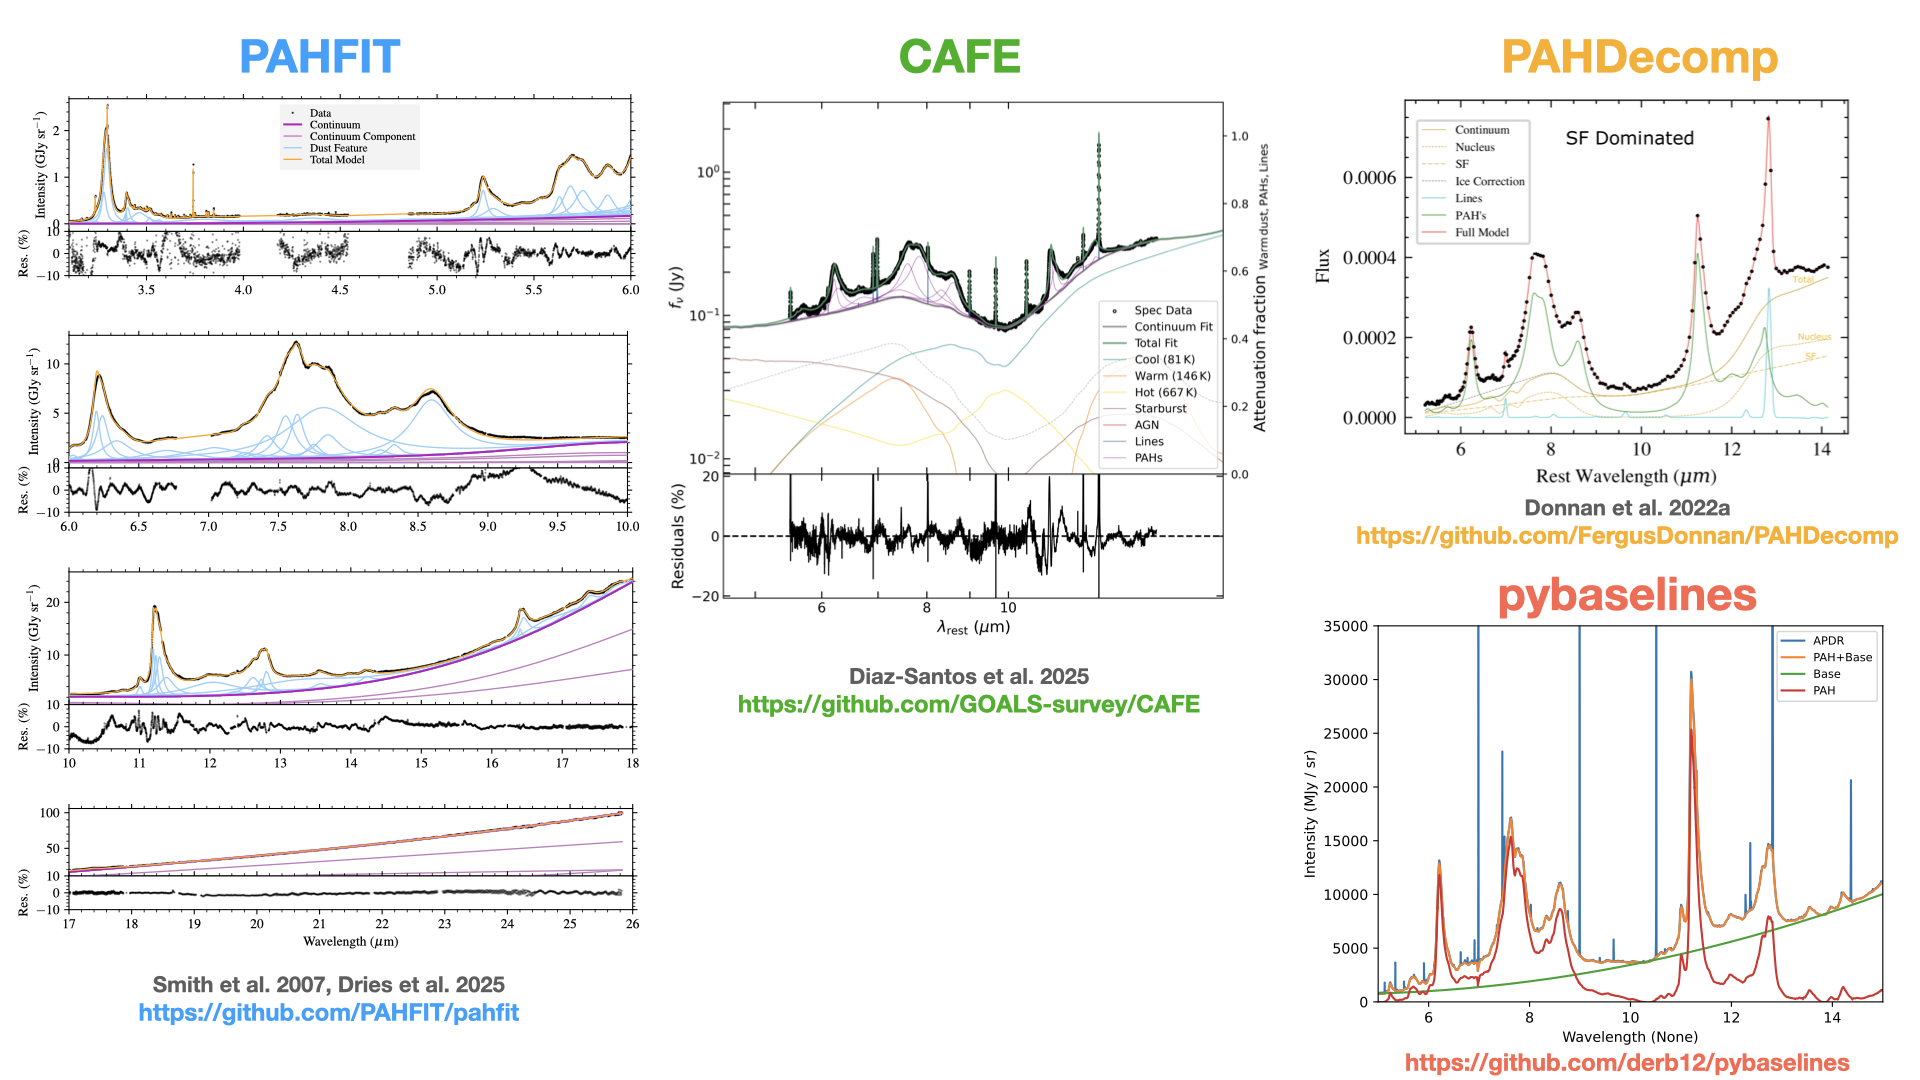

---
<!-- ### <ins>Data input format</ins> -->
### Data input format
- Data types: ascii, ipac, fits
- Data format: "wavelength", "flux", "flux_uncertainty"

<!-- <img src="./plots/PAHdb_input_data_format.png"> -->
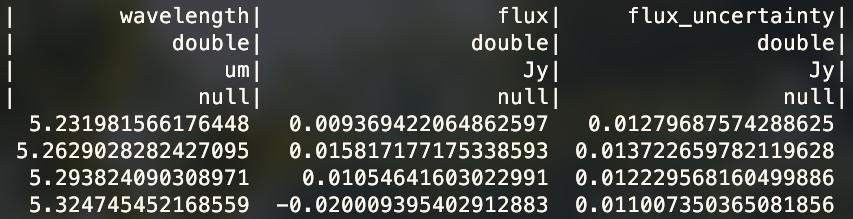

---
## 2. AmesPAHdbPythonSuite Installation
---

The AmesPAHdbPythonSuite can be directly installed from its repository using pip:

Alternatively the AmesPAHdbPythonSuite can be cloned and then installed:

Then change directories to the new AmesPAHdbPythonSuite directory and install:

---
## 3. Using AmesPAHdbPythonSuite
---

### Imports

In [1]:
# Import modules
import pickle

from amespahdbpythonsuite.amespahdb import AmesPAHdb
from amespahdbpythonsuite import observation


### Parse the database

In [3]:
# Database file
xml = 'pahdb-complete-theoretical-v4.00-alpha.xml'

# Parse database 
pahdb = AmesPAHdb(filename=xml, cache=True)

                 AmesPAHdbPythonSuite
                 
                          by
                          
                Dr. Christiaan Boersma
                
                          and
                         
             Dr. Alexandros Maragkoudakis
             
               Dr. Matthew J. Shannanon
               
                  Dr. Joseph E. Roser
                 

          SUITE VERSION: 0.5.0.post77+ge1dfed1         

           WEBSITE: WWW.ASTROCHEM.ORG/PAHDB/           

          CONTACT: CHRISTIAAN.BOERSMA@NASA.GOV         

             RESTORING DATABASE FROM CACHE             

==
FILENAME                    : /var/folders/45/x25kzx515kd28plk4n3_gy0r0000gp/T/a4dc541fbf033c4cf55e510c874ed3a3.pkl
ORIGNINAL FILENAME          : pahdb-complete-theoretical-v4.00-alpha.xml
PARSE TIME                  : 0:00:01.309124
DATABASE                    : theoretical
VERSION (DATE)              : 4.00-alpha (2025-01-01)
COMMENT                     : 

This is the NA

### Let's check some molecular properties!

In [4]:
# Select PAHs
uids = [18, 717]  # UID 18 = coronene (C24H12), UID 717 = fullerene C60

pahs = pahdb.getspeciesbyuid(uids)
pahs.print()


FORMULA   : C24H12
CHARGE    : 0
SYMMETRY  : 1-A1G
WEIGHT    : 300.0939
TOTAL_E   : -920.70246996
VIB_E     : 177.9517
METHOD    : RB3LYP
N_SOLO    : 0
N_DUO     : 12
N_TRIO    : 0
N_QUARTET : 0
N_QUINTET : 0
N_CH2     : 0
N_CHX     : 0
N_C       : 24
N_H       : 12
N_N       : 0
N_O       : 0
N_MG      : 0
N_SI      : 0
N_FE      : 0
COMMENT   : #becke3lyp/4-31G freq geom=check guess=check
# scf=(novaracc,conver=8  int=(grid=ultrafine)
REFERENCE : Ricca, A., Bauschlicher, Jr., C.W., Boersma, C., Tielens, A.G.G.M., Allamandola, L.J., "The Infrared Spectroscopy of Compact Polycyclic Aromatic Hydrocarbons Containing Up To 384 Carbons", 2012, ApJ, 754, 75 doi:10.1088/0004-637x/754/1/75
REFERENCE : Langhoff, S.R., "Theoretical Infrared Spectra for Polycyclic Aromatic Hydrocarbon Neutrals, Cations, and Anions", 1996, J. Phys. Chem., 100, 2819 doi:10.1021/jp952074g
FORMULA   : C60
CHARGE    : 0
SYMMETRY  : 1-AG
WEIGHT    : 720
TOTAL_E   : -2286.17422799
VIB_E     : 235.2799
METHOD    : RB3LY

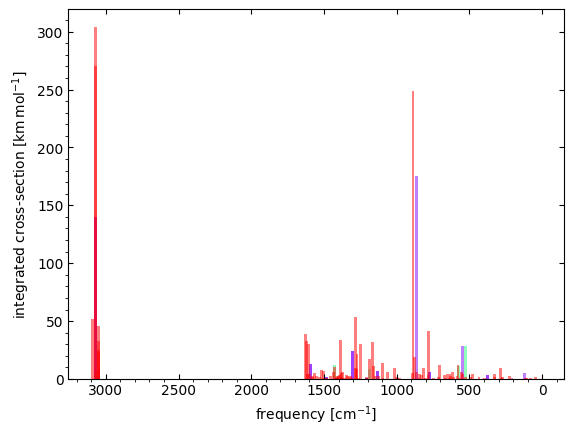

TRANSITIONS
UID: 18
frequency [1 / cm]    integrated cross-sec  symmetry  scale
87.5367               0.0                   E2U       0.9563
87.5367               0.0                   E2U       0.9563
122.5917              4.8786                A2U       0.9563
162.9425              0.0                   B1G       0.9563
223.5094              0.0                   B2G       0.9563
290.0117              0.0                   E1G       0.9563
290.0117              0.0                   E1G       0.9563
296.6587              0.0                   E2U       0.9563
296.6587              0.0                   E2U       0.9563
363.5023              0.0                   E2G       0.9563
363.5023              0.0                   E2G       0.9563
377.6961              3.1458                E1U       0.9563
377.6961              3.146                 E1U       0.9563
447.6036              0.0                   E1G       0.9563
447.6036              0.0                   E1G       0.9563
468.3

In [47]:
# Get transitions and plot stick spectrum
transitions = pahdb.gettransitionsbyuid(uids)
transitions.plot(show=True)
transitions.print()

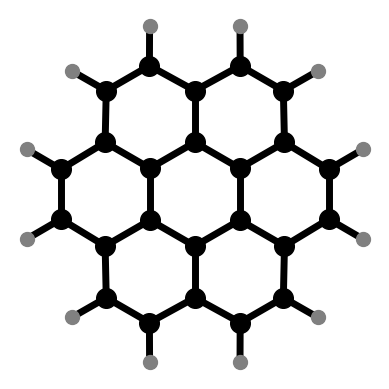

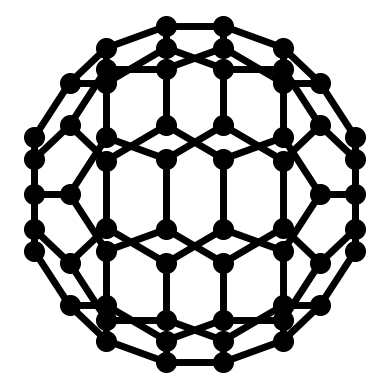

In [5]:
# Plot geometry
geometry = pahdb.getgeometrybyuid(uids)
geometry.diagonalize()
geometry.plot(18)
geometry.plot(717)

In [ ]:
# Molecular properties.
masses = geometry.mass()  # calculated mass based on atomic masses 
rings = geometry.rings()  # the number of 3-8 membered rings
areas = geometry.area()  # total surface area of the PAH molecules
bec = geometry.bec()  # boundary-edge code

print(masses)
print(rings)
print(areas)
print(bec)

{18: 300.35928000000007, 717: 720.6599999999997}
{18: {'three': 0, 'four': 0, 'five': 0, 'six': 7, 'seven': 0, 'eight': 0}, 717: {'three': 0, 'four': 0, 'five': 12, 'six': 20, 'seven': 0, 'eight': 0}}
{18: 35.629999999999995, 717: 142.24}
{18: '333333', 717: '11'}


### Inspect the structure



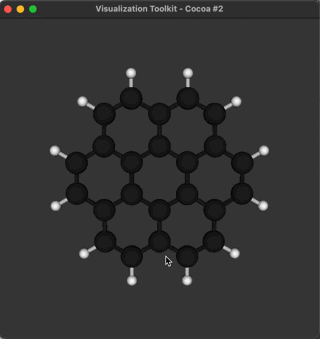

## Fitting a spectrum

### Read-in observations

In [6]:
# Create observations object
specfile = 'PDRs4All_MIRI-MRS_APDR_Template.ipac'
obs = observation.Observation(specfile)

# Convert to wavenumber.
obs.abscissaunitsto("1/cm")

print(obs.spectrum)


Spectrum1D (length=19959)
Flux=[ 238.38613     240.0333379   242.18751017 ... 1120.85847557
      1120.04391181 1119.22931244] MJy / sr,  mean=3076.88969 MJy / sr
Spectral Axis=[1818.13659617 1817.97926224 1817.82195554 ...  666.71893743
                666.69777923  666.67662237] 1 / cm,  mean=1056.11504 1 / cm
Uncertainty=StdDevUncertainty ([68.219 68.219 68.49  ... 32.765 31.291 30.539] MJy / sr)


### Selection of PAHs for modeling and fitting

In [7]:
# Select PAHs
uids = pahdb.search(
    'magnesium=0 oxygen=0 iron=0 silicium=0 nitrogen=0 chx=0 ch2=0 c>20 hydrogen>0'
)
# Include fullerenes
fullerenes = [717, 720, 723, 735, 736, 737]

# Update uids
uids = uids + fullerenes
print('Number of selected PAHs: ', len(uids))

Number of selected PAHs:  7529


### Apply emission model, create PAHs emission spectra

#### Available emission models
- FixedTemperature
- CalculatedTemperature
- **Cascade**

In [8]:
# Retrieve the transitions from the database for the subset of PAHs 
transitions = pahdb.gettransitionsbyuid(uids)

# Calculate the emission spectrum at the temperature reached 
# after absorbing a photon in the provided energy (eV CGS units) 
transitions.cascade(7 * 1.603e-12, multiprocessing=True, caching=True)

# Dump transitions object into pickle
configuration = 'PurePAHs_cascade_7eV'
pahdbtrans = f"PAHdb_{configuration}_transitions.pkl"

pickle.dump(transitions.get(), open(pahdbtrans, 'wb'))

# Convolve the bands using Gaussian profile with FWHM of 15 /cm 
spectrum = transitions.convolve(
    grid=obs.getgrid(), fwhm=15.0, gaussian=True, multiprocessing=True
)

  RESTORING CASCADE: 3BA623F3B5AF52F1812733FACA953A6B  

              USING GAUSSIAN LINE PROFILES             

  GRID: (XMIN,XMAX)=(666.677, 1818.137); 19959 POINTS  

                     FWHM: 15.0 /cm                    

           USING MULTIPROCESSING WITH 9 CORES          



In [10]:
# Dump spectrum-object into pickle
basename = specfile.split('.ipac')[0]
pahdbspec = f"{basename}_{configuration}_spectrum_object.pkl"

pickle.dump(spectrum.get(), open(pahdbspec, 'wb'))

### Fit the spectrum

#### Standard fitting (NNLS, NNLC)

In [11]:
fit = spectrum.fit(obs, multiprocessing=True, notice=False)

### Plotting results

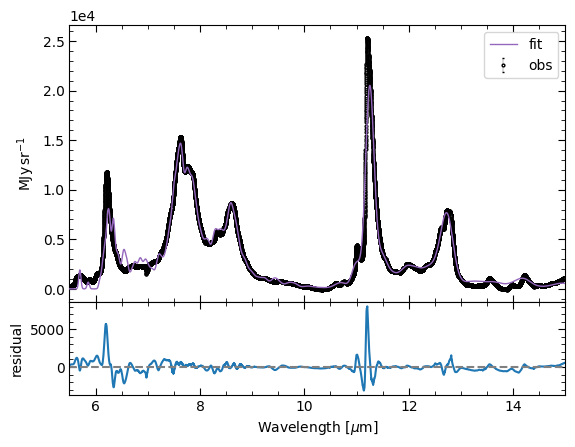

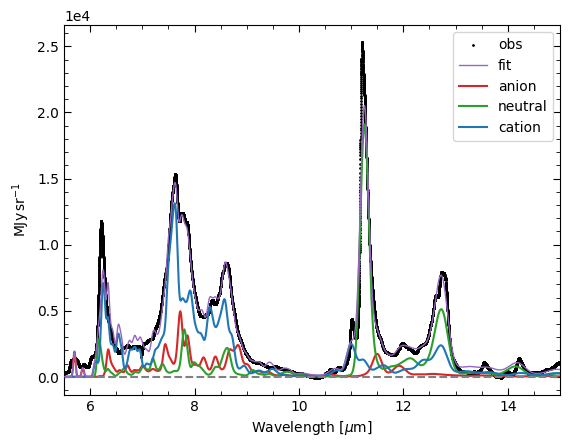

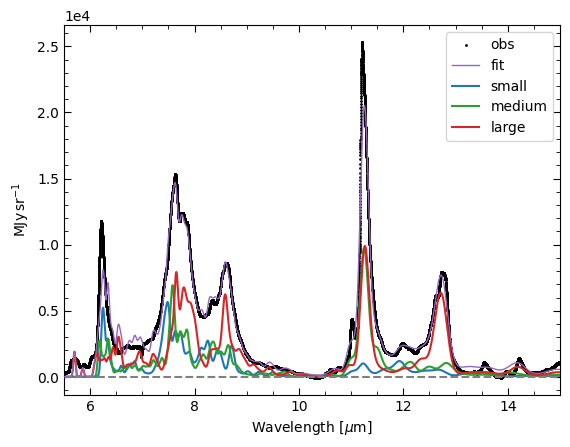

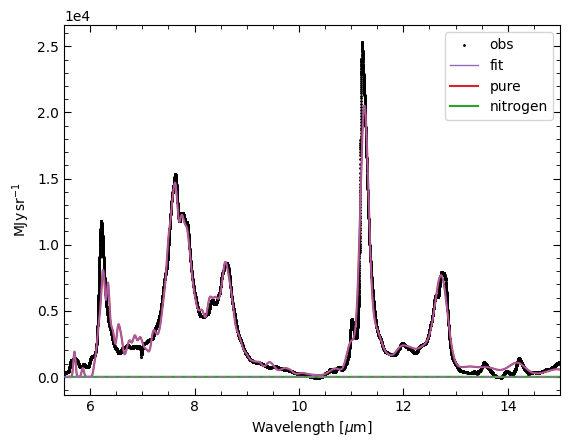

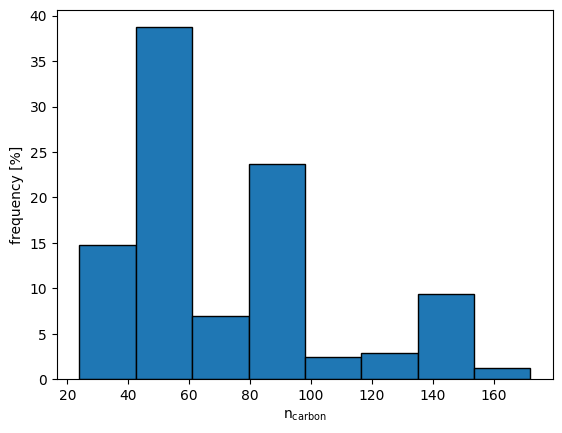

In [64]:
# Create plots.
plotfile = f'{basename}_{configuration}' 
sigma = obs.spectrum.uncertainty.array

fit.plot(
    wavelength=True,
    residual=True,
    sigma=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    charge=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    size=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    composition=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)

fit.plot(sizedistribution=True)

### Inspect fit breakdown and statistics

In [12]:
# Get fit breakdown.
bd = fit.getbreakdown()

# Print key, value pairs.
for k, v in bd.items():
    print(f'{k}: {v}')

# Dump fit breakdown into pickle
pahdbbd = f"PAHdb_{basename}_fit-breakdown.pkl"
pickle.dump(bd, open(pahdbbd, 'wb'))

solo: 305
duo: 528
trio: 279
quartet: 72
quintet: 0
anion: 0.18804148432349238
neutral: 0.28430442328472333
cation: 0.5276540923917843
small: 0.24392741095854314
medium: 0.3109815430055703
large: 0.4450910460358867
nitrogen: 0.0
pure: 1.0
n_c: 75.00241065842476


### Get information on the contributing PAHs

In [13]:
fp = fit.sort(flux=True)

# Dump fit object into pickle
pahdbfit = f"PAHdb_{basename}_fit-PAHs.pkl"
pickle.dump(fp, open(pahdbfit, 'wb'))

### MC fitting

- Mention you can get all the statistics from the MC fits, add a line of code to show it.

In [ ]:
# Fit the spectrum using Monte Carlo approach.
mcfit = spectrum.mcfit(obs, samples=10, multiprocessing=False)

mcfit.plot(wavelength=True, residual=True)
mcfit.plot(wavelength=True, size=True)
mcfit.plot(wavelength=True, charge=True)
mcfit.plot(wavelength=True, composition=True)
mcfit.plot(wavelength=True, save=True, ftype="pdf")

### Save some time for the next PAHdb runs!

#### Load spectrum or transitions pickle

In [ ]:
import os

# Check if there is a spectrum pickle
if os.path.isfile(pahdbspec):
    from amespahdbpythonsuite import spectrum
    # Load spectrum pickle
    spec_pkl = pickle.load(open(pahdbspec, 'rb'))
    print('PAHdb spectrum pickle found and loaded.')
    # Create spectrum object
    spectrum = spectrum.Spectrum(spec_pkl, **{
        'pahdb': pahdb.getdatabaseref(),
        'grid': spec_pkl['grid'],
        f'{spec_pkl["profile"]}': True,
        'fwhm': spec_pkl['fwhm']
    }
    )
else:
    # Check if there is a transitions pickle
    if os.path.isfile(pahdbtrans):
        from amespahdbpythonsuite.transitions import Transitions
        # Load transitions pickle
        trans_pkl = pickle.load(open(pahdbtrans, 'rb'))
        print('PAHdb transitions pickle found and loaded.')
        # Create transitions object
        transitions = Transitions(trans_pkl, pahdb=pahdb.getdatabaseref())
